<a href="https://colab.research.google.com/github/josenomberto/UTEC-CDIAV3-MCD8012/blob/main/laboratorioCalificado4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Instalar ultralytics

In [1]:
!pip -q install ultralytics # Instalamos Ultralytics (nos permitirá usar YOLO)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.3 MB/s eta 0:00:00


### 2. Descomprimir dataset

In [2]:
!unzip datasets.zip

Archive:  datasets.zip
   creating: datasets/
   creating: datasets/BCCD/
   creating: datasets/BCCD/labels/
   creating: datasets/BCCD/labels/train/
  inflating: datasets/BCCD/labels/train/BloodImage_00339.txt  
  inflating: datasets/BCCD/labels/train/BloodImage_00287.txt  
  inflating: datasets/BCCD/labels/train/BloodImage_00107.txt  
  inflating: datasets/BCCD/labels/train/BloodImage_00305.txt  
  inflating: datasets/BCCD/labels/train/BloodImage_00089.txt  
  inflating: datasets/BCCD/labels/train/BloodImage_00311.txt  
  inflating: datasets/BCCD/labels/train/BloodImage_00199.txt  
  inflating: datasets/BCCD/labels/train/BloodImage_00193.txt  
  inflating: datasets/BCCD/labels/train/BloodImage_00204.txt  
  inflating: datasets/BCCD/labels/train/BloodImage_00077.txt  
  inflating: datasets/BCCD/labels/train/BloodImage_00083.txt  
  inflating: datasets/BCCD/labels/train/BloodImage_00247.txt  
  inflating: datasets/BCCD/labels/train/BloodImage_00212.txt  
  inflating: datasets/BCCD/labe

### 3. Importar librerias

In [15]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from ultralytics import YOLO

### 4. Cargar el modelo YOLOv8 nano preentrenado

In [30]:
MODEL_BASE = "yolov8n.pt"

print(f"--- Iniciando Fine-Tuning de {MODEL_BASE} ---")

# Cargar el modelo YOLOv8n preentrenado en COCO
model_ft = YOLO(MODEL_BASE)

--- Iniciando Fine-Tuning de yolov8n.pt ---


### 5. Definir constantes e hiperparámetros

In [31]:
#DATA_YAML = "bccd.yaml"            # Archivo de configuración del dataset BCCD
#MAX_EPOCHS = 50                    # Restricción: Máximo de 50 épocas
#IMAGE_SIZE = 640                   # Restricción: Tamaño de imagen <= 640
#BATCH_SIZE = 16                    # Tamaño de lote balanceado para estabilidad y VRAM
#OPTIMIZER_TYPE = "SGD"            # Optimizador clásico solicitado
#EARLY_STOPPING_PATIENCE = 10      # Detiene el entrenamiento si no mejora en 10 épocas
#OPTIMIZER_TYPE = "AdamW"           # Optimizador mejorado
#EARLY_STOPPING_PATIENCE = 10       # Detiene el entrenamiento si no mejora en 15 épocas
#FREEZE_LAYERS = 10                 # Congela las primeras 10 capas del backbone
#EXPERIMENT_NAME = "y8_bccd_ft_opt" # Nombre identificador del experimento


#DATA_YAML = "bccd.yaml"            # Archivo de configuración del dataset BCCD
#MAX_EPOCHS = 50                    # Restricción: Máximo de 50 épocas
#IMAGE_SIZE = 640                   # Restricción: Tamaño de imagen <= 640
#BATCH_SIZE = 16                    # Tamaño de lote balanceado para estabilidad y VRAM
#OPTIMIZER_TYPE = "SGD"            # Optimizador clásico solicitado
#EARLY_STOPPING_PATIENCE = 10      # Detiene el entrenamiento si no mejora en 10 épocas
#OPTIMIZER_TYPE = "AdamW"           # Optimizador mejorado
#EARLY_STOPPING_PATIENCE = 15       # Detiene el entrenamiento si no mejora en 15 épocas
#FREEZE_LAYERS = 5                 # Congela las primeras 10 capas del backbone
#EXPERIMENT_NAME = "y8_bccd_ft_opt" # Nombre identificador del experimento


DATA_YAML = "bccd.yaml"            # Archivo de configuración del dataset BCCD
MAX_EPOCHS = 50                    # Restricción: Máximo de 50 épocas
IMAGE_SIZE = 640                   # Restricción: Tamaño de imagen <= 640
BATCH_SIZE = 16                    # Tamaño de lote balanceado para estabilidad y VRAM
#OPTIMIZER_TYPE = "SGD"            # Optimizador clásico solicitado
#EARLY_STOPPING_PATIENCE = 10      # Detiene el entrenamiento si no mejora en 10 épocas
OPTIMIZER_TYPE = "AdamW"           # Optimizador mejorado
EARLY_STOPPING_PATIENCE = 15       # Detiene el entrenamiento si no mejora en 15 épocas
FREEZE_LAYERS = 2                 # Congela las primeras 10 capas del backbone
EXPERIMENT_NAME = "y8_bccd_ft_opt" # Nombre identificador del experimento



print(f"Restricciones: Épocas={MAX_EPOCHS}, Tamaño Imagen={IMAGE_SIZE}")
print(f"Estrategia FT: Optimizador={OPTIMIZER_TYPE}, Capas Congeladas={FREEZE_LAYERS}")


Restricciones: Épocas=50, Tamaño Imagen=640
Estrategia FT: Optimizador=AdamW, Capas Congeladas=2


### 6. Re-entrenamiento de modelo

In [32]:
# Lanzar el proceso de entrenamiento (Fine-Tuning)
results = model_ft.train(
    data=DATA_YAML,
    epochs=MAX_EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    optimizer=OPTIMIZER_TYPE,
    patience=EARLY_STOPPING_PATIENCE,
    freeze=FREEZE_LAYERS,
    name=EXPERIMENT_NAME,
    device=0,                     # Forzar el uso de la GPU (CUDA:0)
    plots=True                    # Generar automáticamente gráficos de entrenamiento
)
print("\n--- Entrenamiento Finalizado con Éxito ---")

# 4. Mostrar ruta de guardado y los resultados principales de validación
save_dir = results.save_dir
print(f"Todos los resultados y gráficas han sido guardados en: {save_dir}")


Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=bccd.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=2, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=y8_bccd_ft_opt-5, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patien

### 6. Mostrar Métricas

In [22]:
# Obtener y desplegar métricas en consola
metrics = results.results_dict
print("\nResumen de Métricas Globales (all):")
print(f"- Precision (P):   {metrics.get('metrics/precision(B)', 0):.3f}")
print(f"- Recall (R):      {metrics.get('metrics/recall(B)', 0):.3f}")
print(f"- mAP50:           {metrics.get('metrics/mAP50(B)', 0):.3f}")
print(f"- mAP50-95:        {metrics.get('metrics/mAP50-95(B)', 0):.3f}")




Resumen de Métricas Globales (all):
- Precision (P):   0.830
- Recall (R):      0.906
- mAP50:           0.912
- mAP50-95:        0.611


### 8. Curvas de Pérdida y Métricas

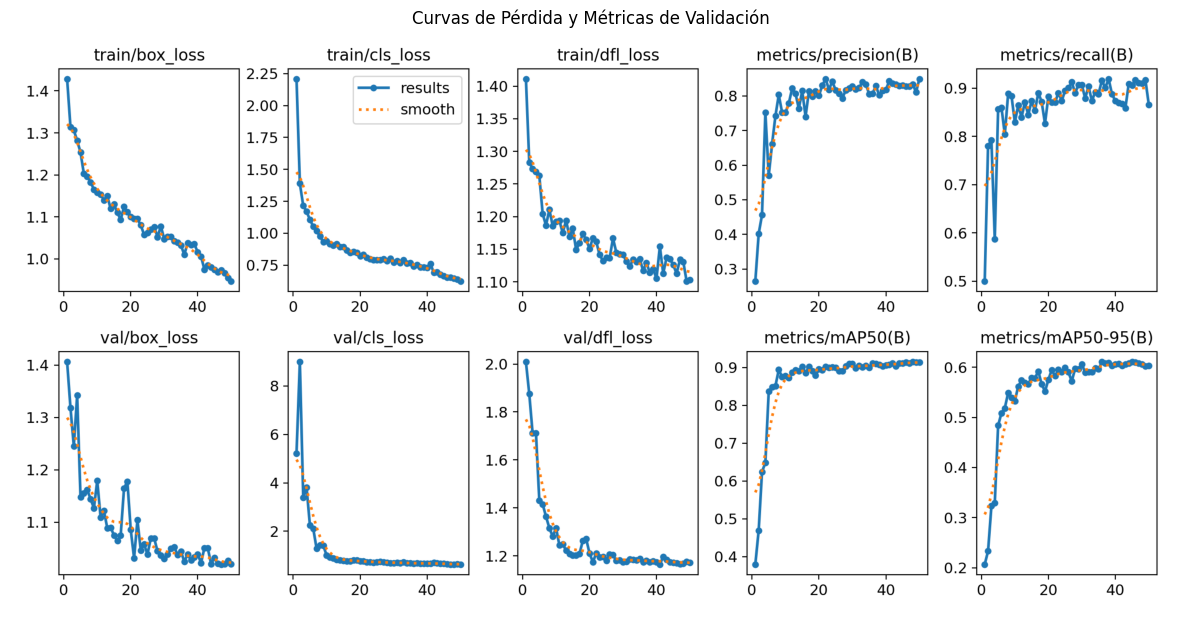

In [25]:
# Ultralytics guarda automáticamente un resumen del entrenamiento en el archivo 'results.png'
img_path = f'{save_dir}/results.png'

try:
    img = mpimg.imread(img_path)
    plt.figure(figsize=(15, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Curvas de Pérdida y Métricas de Validación")
    plt.show()
except FileNotFoundError:
    print("El archivo de resultados visuales aún no se ha generado o la ruta es incorrecta.")


### 7. Modelo con Fine-Tuning en Datos de Validación

In [26]:
metrics = model_ft.val(data="bccd.yaml", imgsz=640, split="val")
print("mAP@0.5 luego de Fine Tuning:", metrics.box.map50)

Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 869.7±382.6 MB/s, size: 19.9 KB)
val: Scanning /content/datasets/BCCD/labels/val.cache... 73 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 73/73 16.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.6it/s 3.1s
                   all         73        964       0.83      0.906      0.912      0.609
                   RBC         69        821      0.778      0.803       0.87      0.615
                   WBC         71         72      0.967          1       0.99      0.788
             Platelets         40         71      0.745      0.915      0.875      0.424
Speed: 5.9ms preprocess, 4.2ms inference, 0.0ms loss, 4.0ms postprocess per image
Results saved to /content/runs/detect/val-2
mAP@0.5 luego 